In [123]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a query that will join Data Set 1 to Data Set 2 to get the sum of api calls by customer classification by date.
Combining two tables, Dataset_1 and Dataset_2, using a left join to maintain all the records from the Dataset_1, using a common field, the customer id.

SQL ver:
```
SELECT
d2.customer_classification,
d1.date,
SUM(api_calls) AS sum_api_calls
FROM Dataset_1  d1--- assuming the name.
LEFT JOIN Dataset_2 d2 
ON d1.customer_id = d2.cust_no
GROUP BY customer_classification, date
```





Getting the dataframes from the csv files.

In [153]:
dataset_1 = pd.read_csv('datasets/dataset_1.csv')[['customer_id','date','api_calls']]
dataset_2 = pd.read_csv('datasets/dataset_2.csv')[['cust_no','customer_classification']]


joining the data and grouping by customer classification and date, then getting the sum of api calls

In [154]:
api_calls = dataset_1.merge(dataset_2, how='left', right_on='cust_no', left_on='customer_id')
api_calls = api_calls.groupby(['customer_classification', 'date'])['api_calls'].sum().to_frame().reset_index()

In [117]:
api_calls.to_csv('results/api_calls.csv')
api_calls

,customer_classification,date,api_calls
0,Large,1/1/21,29857
1,Large,1/10/21,38599
2,Large,1/11/21,76041
3,Large,1/12/21,70945
4,Large,1/13/21,21137
...,...,...,...
82,Small,1/5/21,105657
83,Small,1/6/21,66024
84,Small,1/7/21,83290
85,Small,1/8/21,67132


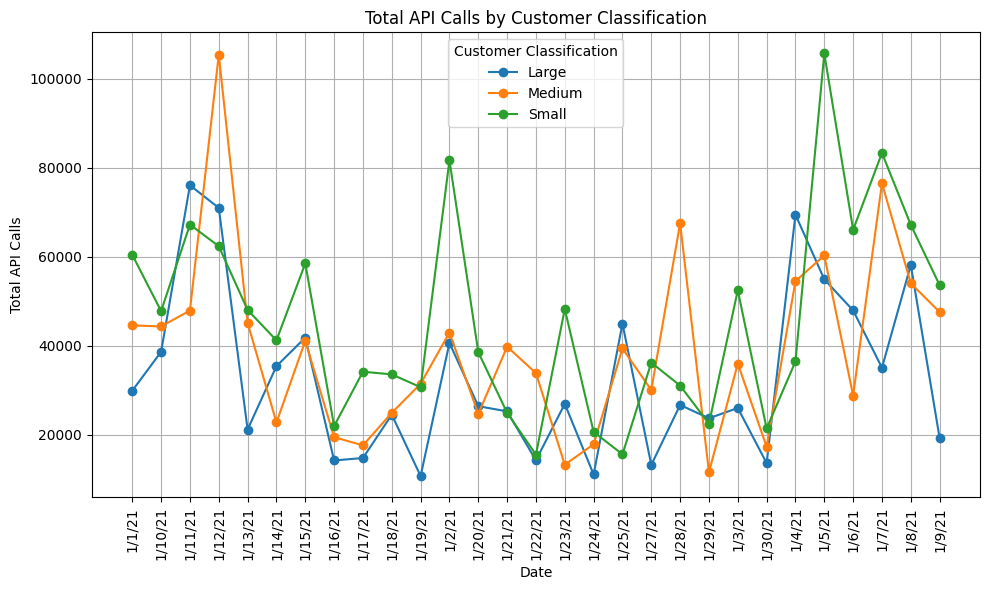

In [158]:
plt.figure(figsize=(10, 6))
for classification in api_calls['customer_classification'].unique():
    subset = api_calls[api_calls['customer_classification'] == classification]
    plt.plot(subset['date'], subset['api_calls'], marker='o', label=classification)
plt.title('Total API Calls by Customer Classification')
plt.xlabel('Date')
plt.ylabel('Total API Calls')
plt.legend(title='Customer Classification')
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Use Data Set 3 to create a year over year trend in total and by customer classification.  Can you say that the growth is statistically significant? 

Gets the year over year calculation using the LAG function
which gets previous row, partioned by the customer classification
and order by the year.
```

SELECT
EXTRACT(YEAR FROM date) AS year,
customer_classification,
SUM(count) AS total,
LAG(SUM(count)) OVER (PARTITION BY customer_classification ORDER BY EXTRACT(YEAR FROM date)) AS year_over_year
FROM dataset3 -- asumming name
GROUP BY EXTRACT(YEAR FROM date) AS year, customer_classification
ORDER BY customer_classification, year
```

Getting the data from csv files

In [144]:
dataset_3 = pd.read_csv('datasets/dataset_3.csv')[['date','customer_classification','count']]

Extracting the year from the date column and grouping by year and customer classification, then getting the total count.

In [145]:
dataset_3['year'] = pd.to_datetime(dataset_3['date'], errors='coerce').dt.year
yoy_trend = dataset_3.groupby(['year','customer_classification'])['count'].sum().reset_index()

/var/folders/c7/zh3ysgkj3kq630rnpldd5c4c0000gn/T/ipykernel_73221/2796573169.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Pivoting the table, this allows us to change the customer_classification into columns, which makes easier to calculate the YOY

In [146]:
yoy_trend = yoy_trend.pivot(index='year', columns='customer_classification', values='count').reset_index()

Shifting the value by one row (getting the previous year value)

In [148]:
yoy_trend['large_last_year'] = yoy_trend['Large'].shift(1)
yoy_trend['medium_last_year'] = yoy_trend['Medium'].shift(1)
yoy_trend['small_last_year'] = yoy_trend['Small'].shift(1)

In [149]:
yoy_trend

customer_classification,year,Large,Medium,Small,large_last_year,medium_last_year,small_last_year
0,2021,352348479,384135526,436653580,NaN,NaN,NaN
1,2022,315071958,300789755,348423056,352348479.0,384135526.0,436653580.0


Getting percentages for the YOY calculation (this year - last year) / last year * 100

In [150]:
yoy_trend['large_absolute'] = yoy_trend['Large'] - yoy_trend['large_last_year']
yoy_trend['medium_absolute'] = yoy_trend['Medium'] - yoy_trend['medium_last_year']
yoy_trend['small_absolute'] = yoy_trend['Small'] - yoy_trend['small_last_year']

yoy_trend['large_percentage'] = (yoy_trend['large_absolute'] / yoy_trend['large_last_year'] * 100).round(2)
yoy_trend['medium_percentage'] = (yoy_trend['medium_absolute'] / yoy_trend['medium_last_year'] * 100).round(2)
yoy_trend['small_percentage'] =( yoy_trend['small_absolute'] / yoy_trend['small_last_year'] * 100).round(2)


In [151]:
yoy_trend.to_csv('results/yoy_trend.csv')
yoy_trend

customer_classification,year,Large,Medium,Small,large_last_year,medium_last_year,small_last_year,large_absolute,medium_absolute,small_absolute,large_percentage,medium_percentage,small_percentage
0,2021,352348479,384135526,436653580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,315071958,300789755,348423056,352348479.0,384135526.0,436653580.0,-37276521.0,-83345771.0,-88230524.0,-10.58,-21.7,-20.21


#### From the last rows, ```large_percentage```, ```medium_percentage``` and so on, from 2021 to 2022, we can see negative values, so we can infer that there's no significant growth.

# Compare Data Set 3 to Data Set 4.  Explain the difference and write a query that would possibly alleviate the difference.  

Based on an initial exploration of both datasets:


1. dataset 3 has three columns ```date```, ``` customer_classification``` and ```count``` while dataset 4 has ```date```, ``` customer_classification__c``` and ```sum_count```.


We could alleviate the differences changing the names from one table, using the ```ALTER TABLE``` clause.

```
ALTER TABLE dataset_4
RENAME COLUMN customer_classification__c TO customer_classification,
RENAME COLUMN sum_count TO count;
```

# Compile a histogram for Data Set 5 by classification and geographic region.  Explain how this data set could depict a shift in strategy over time 

In [139]:
dataset_5 = pd.read_csv('datasets/dataset_5.csv')

In [143]:
## Grouping the data by Classification and geographic region
data_hist =  dataset_5.groupby(['Classification', 'Geo']).size().reset_index(name='class_geo_count')
## Pivoting the table, so it's easier to plot
pivot_table = data_hist.pivot(index='Classification', columns='Geo', values='class_geo_count')

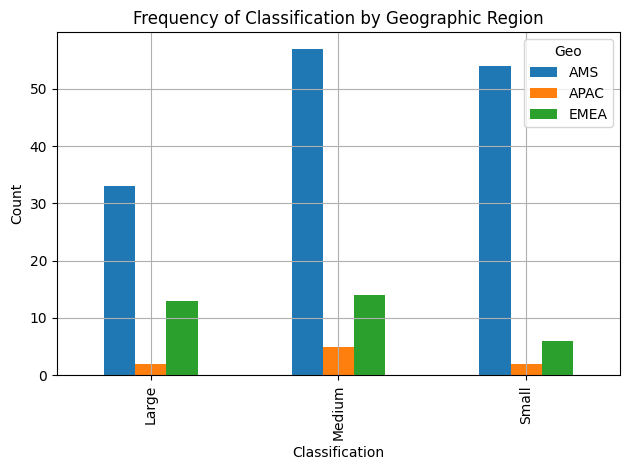

In [142]:
pivot_table.plot(kind='bar', stacked=False)
plt.title('Frequency of Classification by Geographic Region')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.legend(title='Geo')
plt.tight_layout()
plt.grid(True)
plt.show()

From the data, we can infer:

    1. There is an AMS dominance in every classification, specially in medium and small region. 

    2. The lack of focus in APAC might need reprioritization, since we are seeing low counts, specially in small and large classifications.
    
    3. Although we see a small count in the small classification for EMEA, we might need to focus on maintaining the large classification if we want to keep the count in that classification, depends on the strategy we might want to follow.
    
    

# Using a Window function if possible,  write a query that ranks the customers in Data Set 1 by their API usage and segment by the classifications joined from Data Set 2.

We use DENSE_RANK to get the ranking of customers; ranking them by their API usage and segmenting them by their classification.

```
SELECT
customer_id,
customer_classification,
SUM(api_calls) AS sum_api_calls,
DENSE_RANK() OVER (PARTITION BY customer_classification ORDER BY SUM(api_calls) DESC) AS rank
FROM Dataset_1  d1--- assuming the name.
LEFT JOIN Dataset_2 d2 
ON d1.customer_id = d2.cust_no
GROUP BY customer_id, customer_classification

```

Getting the datasets and then joining the data using a left join, since we want to keep all the rows from the left side.

In [152]:
dataset_1 = pd.read_csv('datasets/dataset_1.csv')[['customer_id','date','api_calls']]
dataset_2 = pd.read_csv('datasets/dataset_2.csv')[['cust_no','customer_classification']]
api_calls = dataset_1.merge(dataset_2, how='left', right_on='cust_no', left_on='customer_id')

Group by customer id and customer classification. Also getting the sum of the api calls.

In [103]:
api_calls = api_calls.groupby(['customer_id','customer_classification'])['api_calls'].sum().to_frame().reset_index()

Using the dense rank method to get each customer's api calls by customer_classification.

In [105]:
api_calls['api_usage_rank']=api_calls.groupby('customer_classification')['api_calls'].rank(method='dense', ascending=False)

Sorting values.

In [106]:
api_calls=api_calls.sort_values(['customer_classification','api_usage_rank','customer_id'])

In [102]:
api_calls.to_csv('results/api_call_usage_rank.csv')
api_calls

,customer_id,customer_classification,api_calls,api_usage_rank
211,685,Large,62454,1.0
83,225,Large,42494,2.0
183,604,Large,39260,3.0
189,618,Large,37079,4.0
302,932,Large,30336,5.0
...,...,...,...,...
126,395,Small,1175,192.0
273,860,Small,1169,193.0
446,1579,Small,1146,194.0
36,101,Small,976,195.0


# Write a SQL Script to parse the JSON in Data Set 6 to return the Type, Trigger ID, and Trigger Type.

We can use JSON_VALUE function to retrieve the contents of a json.

```
SELECT
JSON_VALUE(CONTENT_JSON, $.definition.steps.myStart.type) as Type,
JSON_VALUE(CONTENT_JSON, $.trigger.triggerId) as TriggerId,
JSON_VALUE(CONTENT_JSON, $.trigger.triggerType) as TriggerType
FROM Dataset_6
```